In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
os.chdir('d:/flujo_portables/NormativeModel_EEG')
from run_config_params.DATASET import Dortmund, CHBMP, GREECE, AR, CL, PORTABLES_CE, BIOMARCADORES, CAUEEG_CONCAT, Poland, SRM, Madrid_c3n


In [2]:
renombrar_grupos = {'G2': 'HC', 'GU': 'HC', 'CTR': 'HC', 'DCL': 'MCI','DTA':'AD','A':'AD','G1':'ACr','GG':'ACr'}

In [3]:
dem_Dortmund = pd.read_excel(rf"{Dortmund['demographic']}")
dem_Dortmund['group'] = dem_Dortmund['group'].replace(renombrar_grupos)

dem_CHBMP = pd.read_excel(rf"{CHBMP['demographic']}")
dem_CHBMP['group'] = dem_CHBMP['group'].replace(renombrar_grupos)

dem_GREECE = pd.read_excel(rf"{GREECE['demographic']}")
dem_GREECE['group'] = dem_GREECE['group'].replace(renombrar_grupos)

dem_AR = pd.read_excel(rf"{AR['demographic']}")
dem_AR['group'] = dem_AR['group'].replace(renombrar_grupos)

dem_CL = pd.read_excel(rf"{CL['demographic']}")
dem_CL['group'] = dem_CL['group'].replace(renombrar_grupos)

dem_PORTABLES_CE = pd.read_excel(rf"{PORTABLES_CE['demographic']}")
dem_PORTABLES_CE['group'] = dem_PORTABLES_CE['group'].replace(renombrar_grupos)

dem_BIOMARCADORES = pd.read_excel(rf"{BIOMARCADORES['demographic']}")
dem_BIOMARCADORES['group'] = dem_BIOMARCADORES['group'].replace(renombrar_grupos)

dem_CAUEEG_CONCAT = pd.read_excel(rf"{CAUEEG_CONCAT['demographic']}")
dem_CAUEEG_CONCAT['group'] = dem_CAUEEG_CONCAT['group'].replace(renombrar_grupos)

dem_Poland = pd.read_excel(rf"{Poland['demographic']}")
dem_Poland['group'] = dem_Poland['group'].replace(renombrar_grupos)

dem_SRM = pd.read_excel(rf"{SRM['demographic']}")
dem_SRM['group'] = dem_SRM['group'].replace(renombrar_grupos)

dem_Madrid_c3n = pd.read_excel(rf"{Madrid_c3n['demographic']}")
dem_Madrid_c3n['group'] = dem_Madrid_c3n['group'].replace(renombrar_grupos)

dfs =[dem_Dortmund, dem_CHBMP, dem_GREECE, dem_AR, dem_CL, dem_PORTABLES_CE, dem_BIOMARCADORES, dem_CAUEEG_CONCAT, dem_Poland, dem_SRM, dem_Madrid_c3n]



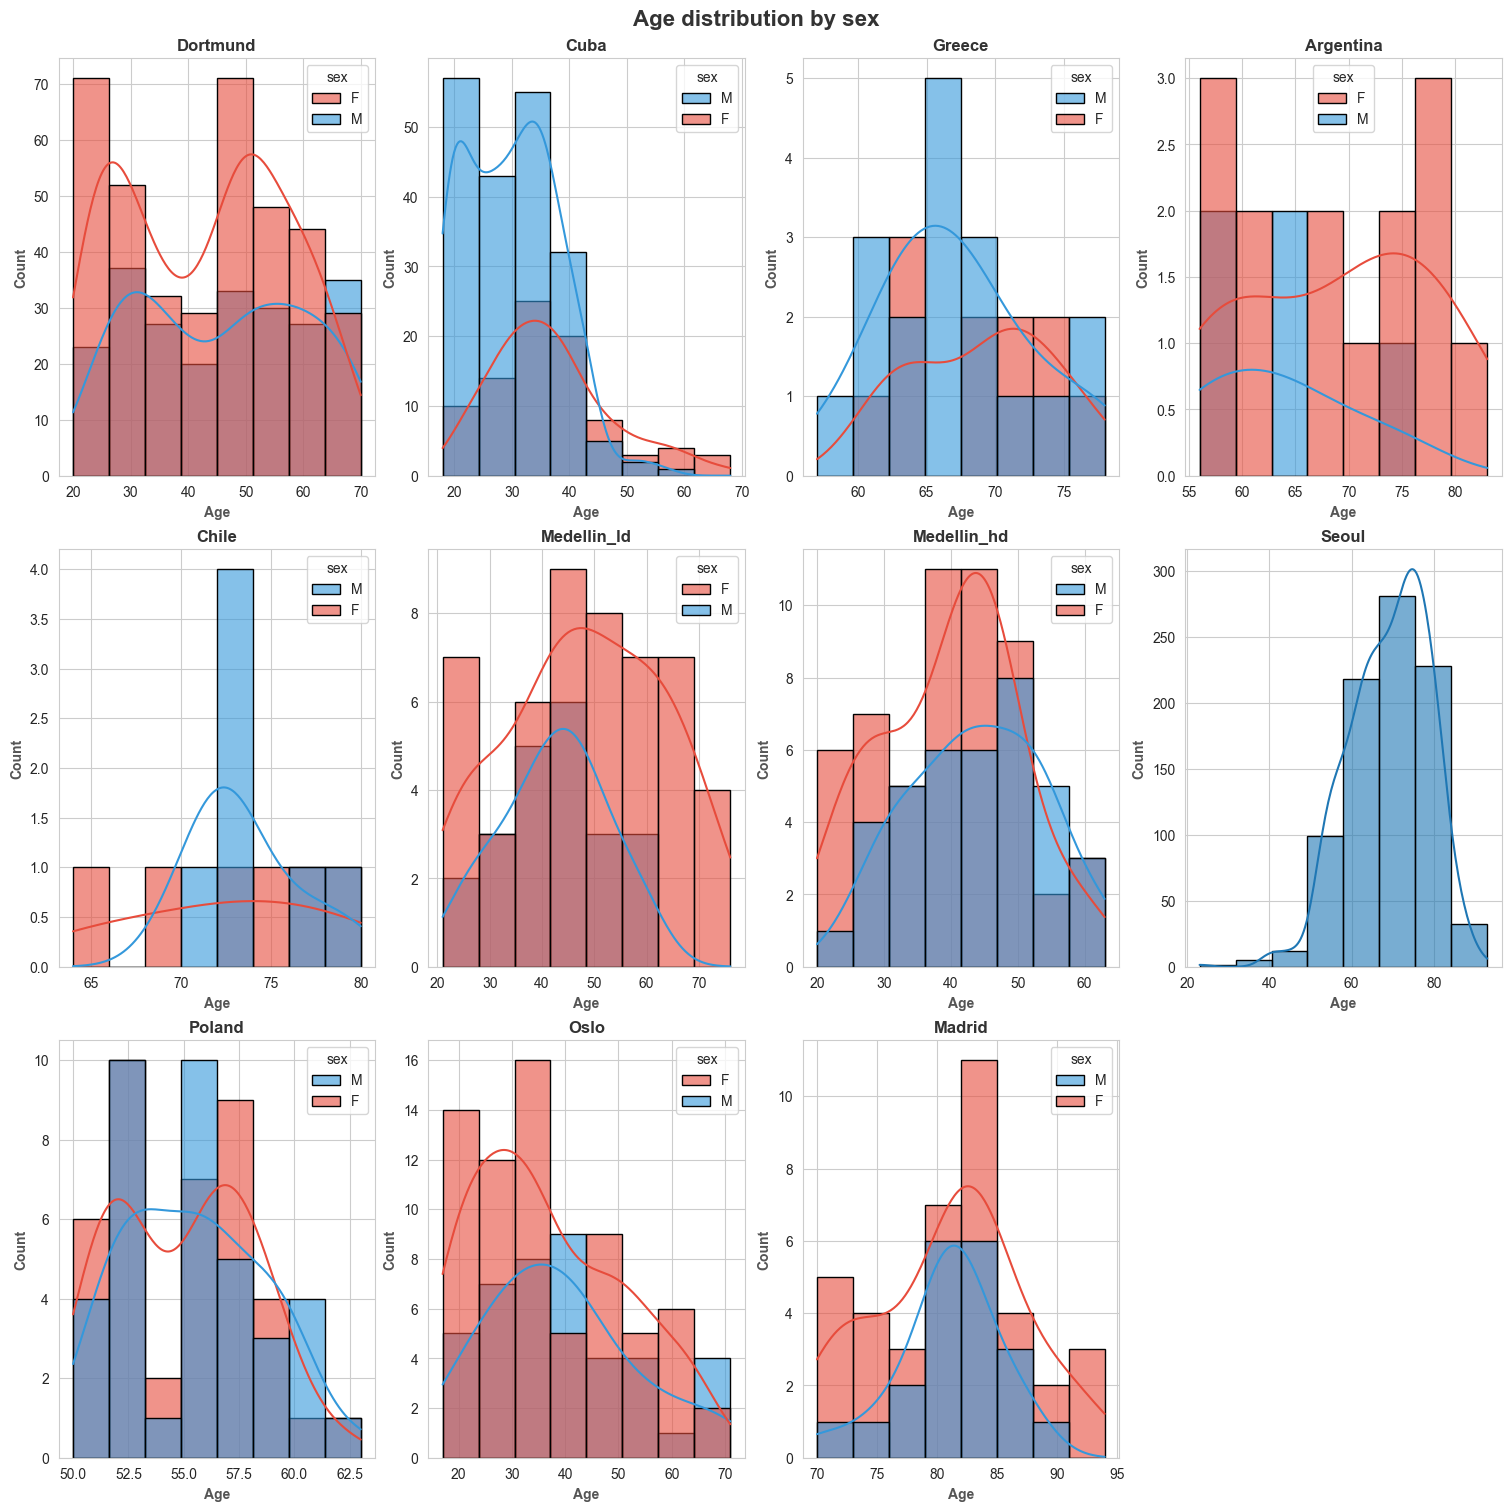

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de DataFrames
dfs = [dem_Dortmund, dem_CHBMP, dem_GREECE, dem_AR, dem_CL, dem_PORTABLES_CE, 
       dem_BIOMARCADORES, dem_CAUEEG_CONCAT, dem_Poland, dem_SRM, dem_Madrid_c3n]

for i in range(len(dfs)):
    dfs[i] = dfs[i][dfs[i]['group'].isin(['HC', 'MCI'])]
    
# Configuración global de estilo
sns.set_style("whitegrid")

# Definir el tamaño de la figura y la distribución de subplots
num_dfs = len(dfs)
cols = 4  # Número de columnas en la cuadrícula de subplots
rows = -(-num_dfs // cols)  # Redondeo hacia arriba para obtener el número de filas

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), constrained_layout=True)

# Convertir `axes` en una lista plana para facilitar la iteración
axes = axes.flatten()

for i, df in enumerate(dfs):
    ax = axes[i]
    df = df[df['group'].isin(['HC', 'MCI'])]
    # Verificar si la columna SITE existe
    site_name = df["SITE"].iloc[0] if "SITE" in df.columns and not df["SITE"].isna().all() else f"Dataset {i+1}"

    # Verificar si la columna 'sex' existe
    if 'sex' not in df.columns:
        sns.histplot(df, x='age', bins=8, kde=True, alpha=0.6, edgecolor='black', ax=ax)
    else:
        sns.histplot(df, x='age', hue='sex', bins=8, kde=True, alpha=0.6, 
                     palette={"M": "#3498db", "F": "#e74c3c"}, edgecolor='black', ax=ax)

    # Mejorando la visualización de cada subplot
    ax.set_xlabel('Age', fontsize=10, fontweight='bold', color='#555')
    ax.set_ylabel('Count', fontsize=10, fontweight='bold', color='#555')
    ax.set_title(f'{site_name}', fontsize=12, fontweight='bold', color='#333')

# Ocultar subplots vacíos si hay menos DataFrames que espacios en la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Título global
plt.suptitle('Age distribution by sex', fontsize=16, fontweight='bold', color='#333')

# Guardar en alta calidad para Overleaf
output_path = r"D:\MulticentersEEG\graphs_thesis_LMZS\age_distribution_data.pdf"
plt.savefig(output_path, dpi=600, format='pdf', bbox_inches='tight', transparent=True)

# Mostrar la figura
plt.show()


C:\Users\Luisa\AppData\Local\Temp\ipykernel_16600\1470853879.py:30: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_16600\1470853879.py:82: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_16600\1470853879.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_hc.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_16600\1470853879.py:132: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_16600\1470853

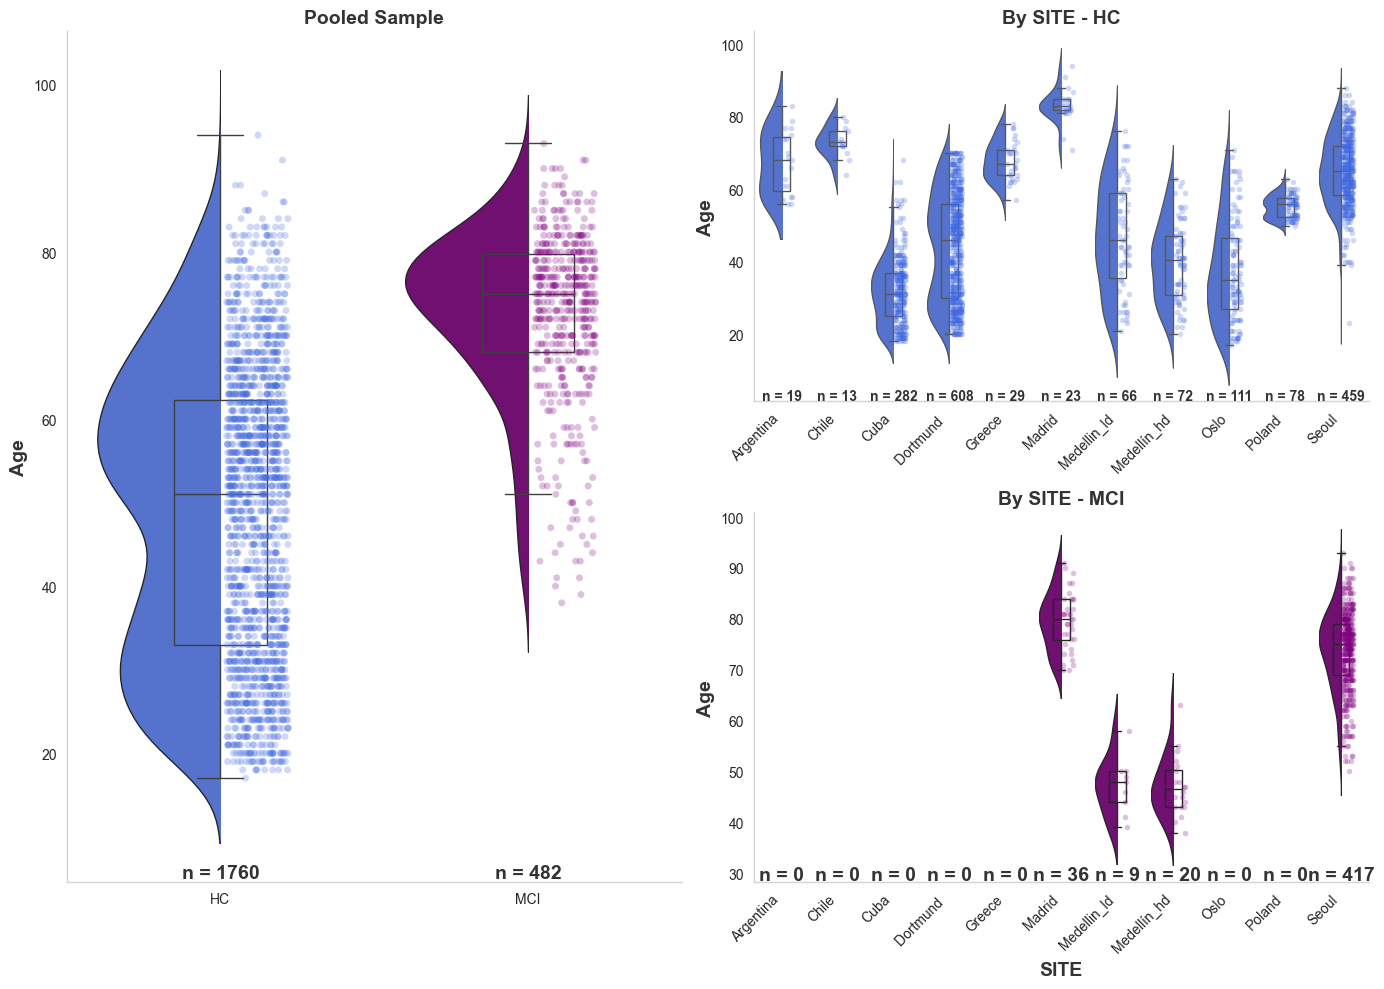

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Unificar datos en un solo DataFrame (asumiendo que 'dfs' es una lista de DataFrames)
all_ages = pd.concat([df[['age', 'group', 'SITE']] 
                      for df in dfs if 'age' in df.columns], 
                     ignore_index=True)

# Definir el orden de grupos y de sitios
group_order = ["HC", "MCI"]
sorted_sites = sorted(all_ages['SITE'].unique(), key=lambda x: str(x))

# Paleta de colores
palette = {'HC': 'royalblue', 'MCI': 'purple'}

# Crear la figura y la cuadrícula: 
# - La primera columna (col=0) ocupará ambas filas (row=0 y row=1) para el pool.
# - La segunda columna (col=1) se divide en dos filas: la superior para HC y la inferior para MCI.
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1])

ax_pool = fig.add_subplot(gs[:, 0])   # Ocupa la columna 0, ambas filas
ax_hc   = fig.add_subplot(gs[0, 1])     # Columna 1, fila superior
ax_mci  = fig.add_subplot(gs[1, 1])     # Columna 1, fila inferior

# ----- POOLED SAMPLE (ax_pool) -----
sns.violinplot(
    x="group", y="age", data=all_ages,
    hue="group", dodge=False,
    palette=palette, scale="width", inner=None,
    ax=ax_pool, linewidth=1, order=group_order
)
# Recortar la mitad izquierda de cada violín
for violin in ax_pool.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_pool.transData)
    )

sns.boxplot(
    x="group", y="age", data=all_ages,
    width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_pool, order=group_order
)
old_len = len(ax_pool.collections)
sns.stripplot(
    x="group", y="age", data=all_ages,
    hue="group", dodge=False,
    palette=palette, ax=ax_pool, alpha=0.25, size=5,
    order=group_order
)
for dots in ax_pool.collections[old_len:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada grupo
group_counts = all_ages.groupby("group")["age"].count().to_dict()
for i, group in enumerate(group_order):
    count = group_counts.get(group, 0)
    ax_pool.text(i, ax_pool.get_ylim()[0] + 0.5, f"n = {count}",
                 ha='center', fontsize=14, fontweight='bold', color='#333')

ax_pool.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_pool.set_xlabel("")
ax_pool.set_title("Pooled Sample", fontsize=14, fontweight='bold', color='#333')
ax_pool.grid(False)
ax_pool.set_facecolor('none')
ax_pool.spines['top'].set_visible(False)
ax_pool.spines['right'].set_visible(False)
for spine in ax_pool.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)

# ----- BY SITE - HC (ax_hc) -----
# Filtrar datos para HC
all_ages_hc = all_ages[all_ages['group'] == 'HC']

sns.violinplot(
    x="SITE", y="age", data=all_ages_hc,
    dodge=False, color=palette['HC'], scale="width", inner=None,
    ax=ax_hc, linewidth=1, order=sorted_sites
)
# Recortar para dejar siempre la mitad izquierda
for violin in ax_hc.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_hc.transData)
    )

sns.boxplot(
    x="SITE", y="age", data=all_ages_hc,
    dodge=False, width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_hc, order=sorted_sites, color=palette['HC']
)
old_len_hc = len(ax_hc.collections)
sns.stripplot(
    x="SITE", y="age", data=all_ages_hc,
    dodge=False, color=palette['HC'], ax=ax_hc, alpha=0.25, size=4,
    order=sorted_sites
)
for dots in ax_hc.collections[old_len_hc:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada sitio en HC
for i, site in enumerate(sorted_sites):
    count = all_ages_hc[all_ages_hc['SITE'] == site].shape[0]
    ax_hc.text(i, ax_hc.get_ylim()[0] + 0.5, f"n = {count}", ha='center',
               fontsize=10, fontweight='bold', color='#333')

ax_hc.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_hc.set_xlabel("")
ax_hc.set_title("By SITE - HC", fontsize=14, fontweight='bold', color='#333')
ax_hc.grid(False)
ax_hc.set_facecolor('none')
ax_hc.spines['top'].set_visible(False)
ax_hc.spines['right'].set_visible(False)
for spine in ax_hc.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)
ax_hc.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)

# ----- BY SITE - MCI (ax_mci) -----
# Filtrar datos para MCI
all_ages_mci = all_ages[all_ages['group'] == 'MCI']

sns.violinplot(
    x="SITE", y="age", data=all_ages_mci,
    dodge=False, color=palette['MCI'], scale="width", inner=None,
    ax=ax_mci, linewidth=1, order=sorted_sites
)
for violin in ax_mci.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_mci.transData)
    )

sns.boxplot(
    x="SITE", y="age", data=all_ages_mci,
    dodge=False, width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_mci, order=sorted_sites, color=palette['MCI']
)
old_len_mci = len(ax_mci.collections)
sns.stripplot(
    x="SITE", y="age", data=all_ages_mci,
    dodge=False, color=palette['MCI'], ax=ax_mci, alpha=0.25, size=4,
    order=sorted_sites
)
for dots in ax_mci.collections[old_len_mci:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada sitio en MCI
for i, site in enumerate(sorted_sites):
    count = all_ages_mci[all_ages_mci['SITE'] == site].shape[0]
    ax_mci.text(i, ax_mci.get_ylim()[0] + 0.5, f"n = {count}", ha='center',
                fontsize=14, fontweight='bold', color='#333')

ax_mci.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_mci.set_xlabel("SITE", fontsize=14, fontweight='bold', color='#333')
ax_mci.set_title("By SITE - MCI", fontsize=14, fontweight='bold', color='#333')
ax_mci.grid(False)
ax_mci.set_facecolor('none')
ax_mci.spines['top'].set_visible(False)
ax_mci.spines['right'].set_visible(False)
for spine in ax_mci.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)
ax_mci.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig(r"D:\MulticentersEEG\graphs_thesis_LMZS\age_distribution_by_site.pdf", dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
path_save = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\IAF_FOOOF_ALL_SENSORS'
IAF_FOOOF_age= pd.read_feather(rf'{path_save}\IAF_FOOOF_age.feather')

C:\Users\Luisa\AppData\Local\Temp\ipykernel_8440\1696623074.py:47: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_8440\1696623074.py:98: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="SITE", y="age", data=IAF_FOOOF_age_hc, color=palette['HC'],
C:\Users\Luisa\AppData\Local\Temp\ipykernel_8440\1696623074.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_hc.set_xticklabels(site_order, rotation=45, ha='right')
C:\Users\Luisa\AppData\Local\Temp\ipykernel_8440\1696623074.py:123: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="SITE", y="ag

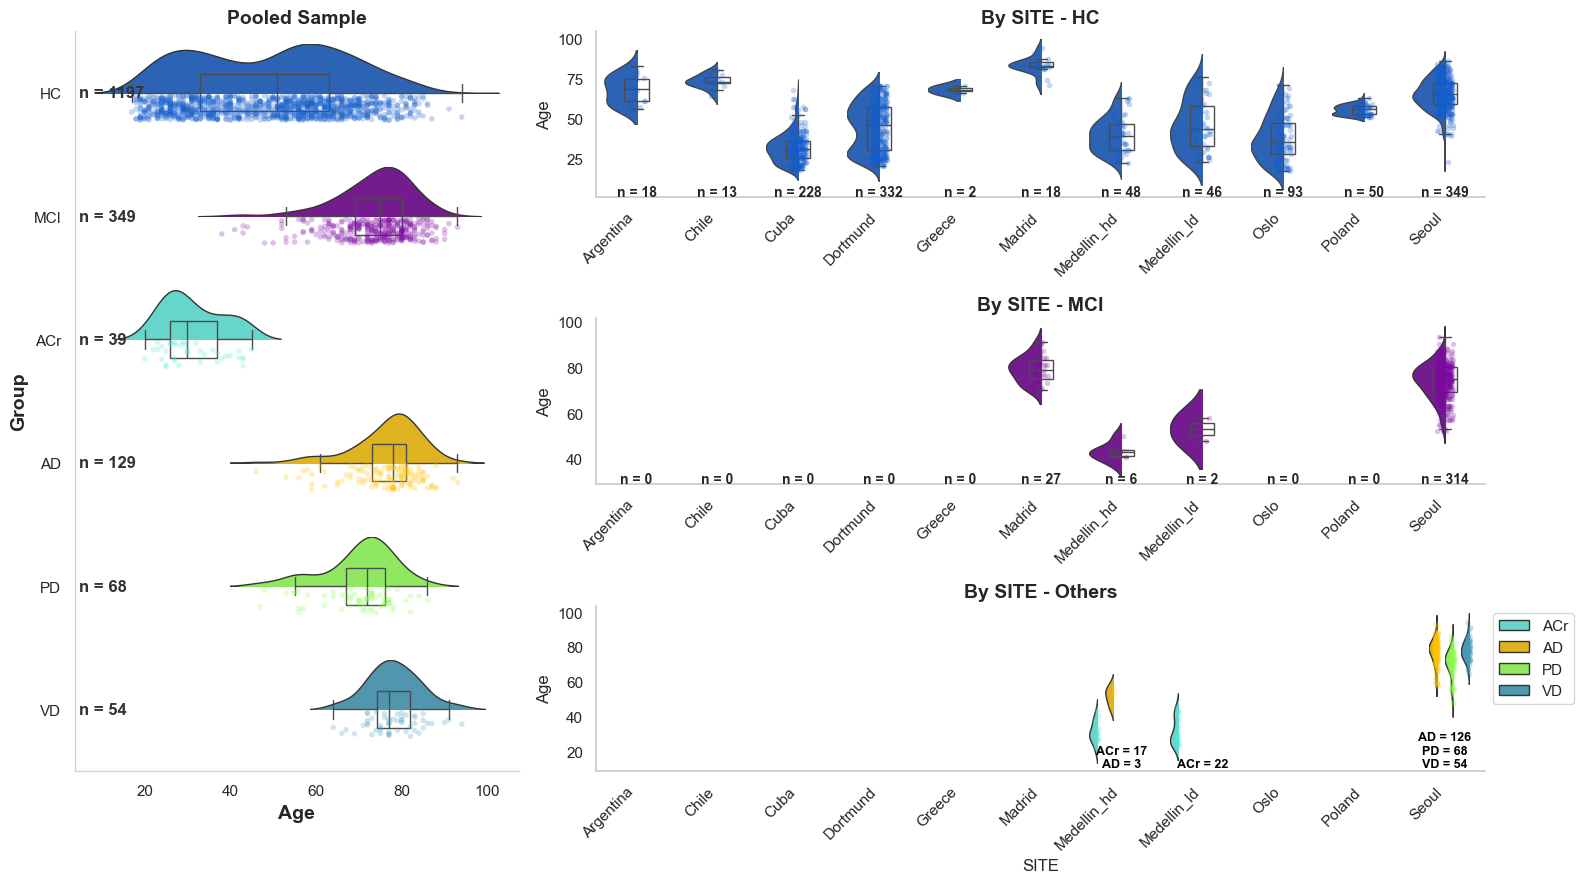

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


# Limpiar y reasignar etiquetas
IAF_FOOOF_age['group'] = IAF_FOOOF_age['group'].replace({
    'DTA': 'AD',
    'A': 'AD',
})

# Filtrar grupos válidos
valid_groups = ['HC', 'MCI', 'ACr', 'AD', 'PD', 'VD']
IAF_FOOOF_age = IAF_FOOOF_age[IAF_FOOOF_age['group'].isin(valid_groups)].copy()

# Mostrar grupos únicos para verificación
IAF_FOOOF_age['group'].value_counts()

# Paleta de colores
palette = {
    'HC': "#155ECC",   # Azul acero
    'MCI': "#7E09A1",  # Azul claro (complementario, pero suave)
    'ACr': "#52e9d8",   # Lila/morado suave
    'AD': '#ffc300',   # Naranja cálido
    'PD': "#88ff49",   # Verde bosque
    'VD': "#429cbd",   # Rojo coral
    
}



group_order = ["HC", "MCI", 'ACr', 'AD', 'PD', 'VD']
site_order = sorted(IAF_FOOOF_age['SITE'].dropna().unique(), key=str)

# Crear figura
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2])

ax_pool = fig.add_subplot(gs[:, 0])  # Ocupa toda la primera columna
ax_hc   = fig.add_subplot(gs[0, 1])
ax_mci  = fig.add_subplot(gs[1, 1])
ax_other = fig.add_subplot(gs[2, 1])

# ========== POOLED SAMPLE ==========

sns.violinplot(
    y="group", x="age", data=IAF_FOOOF_age,
    hue="group", dodge=False,
    palette=palette, scale="width", inner=None,
    ax=ax_pool, linewidth=1, order=group_order
)

for violin in ax_pool.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width, height / 2, transform=ax_pool.transData)
    )

sns.boxplot(
    y="group", x="age", data=IAF_FOOOF_age,
    width=0.3, saturation=1, showfliers=False,
    boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_pool, order=group_order
)

old_len = len(ax_pool.collections)
sns.stripplot(
    y="group", x="age", data=IAF_FOOOF_age,
    hue="group", dodge=False,
    palette=palette, ax=ax_pool, alpha=0.25, size=4,
    order=group_order
)
for dots in ax_pool.collections[old_len:]:
    dots.set_offsets(dots.get_offsets() + np.array([0, 0.12]))

# Etiquetas "n = X"
group_counts = IAF_FOOOF_age.groupby("group")["age"].count().to_dict()
for i, group in enumerate(group_order):
    count = group_counts.get(group, 0)
    ax_pool.text(ax_pool.get_xlim()[0] + 1, i, f"n = {count}",
                 va='center', fontsize=12, fontweight='bold', color='#333')

ax_pool.set_xlabel("Age", fontsize=14, fontweight='bold')
ax_pool.set_ylabel("Group", fontsize=14, fontweight='bold')
ax_pool.set_title("Pooled Sample", fontsize=14, fontweight='bold')
ax_pool.grid(False)
ax_pool.set_facecolor('none')
ax_pool.spines['top'].set_visible(False)
ax_pool.spines['right'].set_visible(False)
for spine in ax_pool.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)

# --- By Site - HC ---
IAF_FOOOF_age_hc = IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'HC']
sns.violinplot(x="SITE", y="age", data=IAF_FOOOF_age_hc, color=palette['HC'],
               scale="width", inner=None, ax=ax_hc, linewidth=1, order=site_order)
for violin in ax_hc.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, w, h = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), w / 2, h, transform=ax_hc.transData))

sns.boxplot(x="SITE", y="age", data=IAF_FOOOF_age_hc, width=0.3, saturation=1,
            showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
            ax=ax_hc, order=site_order)
sns.stripplot(x="SITE", y="age", data=IAF_FOOOF_age_hc, color=palette['HC'], ax=ax_hc,
              alpha=0.25, size=4, order=site_order)
for i, site in enumerate(site_order):
    count = IAF_FOOOF_age_hc[IAF_FOOOF_age_hc['SITE'] == site].shape[0]
    ax_hc.text(i, ax_hc.get_ylim()[0] + 0.5, f"n = {count}",
               ha='center', fontsize=10, fontweight='bold')
ax_hc.set_title("By SITE - HC", fontsize=14, fontweight='bold')
ax_hc.set_ylabel("Age")
ax_hc.set_xlabel("")
ax_hc.set_xticklabels(site_order, rotation=45, ha='right')
ax_hc.spines['top'].set_visible(False)
ax_hc.spines['right'].set_visible(False)
ax_hc.grid(False)
# --- By Site - MCI ---
IAF_FOOOF_age_mci = IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'MCI']
sns.violinplot(x="SITE", y="age", data=IAF_FOOOF_age_mci, color=palette['MCI'],
               scale="width", inner=None, ax=ax_mci, linewidth=1, order=site_order)
for violin in ax_mci.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, w, h = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), w / 2, h, transform=ax_mci.transData))

sns.boxplot(x="SITE", y="age", data=IAF_FOOOF_age_mci, width=0.3, saturation=1,
            showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
            ax=ax_mci, order=site_order)
sns.stripplot(x="SITE", y="age", data=IAF_FOOOF_age_mci, color=palette['MCI'], ax=ax_mci,
              alpha=0.25, size=4, order=site_order)
for i, site in enumerate(site_order):
    count = IAF_FOOOF_age_mci[IAF_FOOOF_age_mci['SITE'] == site].shape[0]
    ax_mci.text(i, ax_mci.get_ylim()[0] + 0.5, f"n = {count}",
                ha='center', fontsize=10, fontweight='bold')
ax_mci.set_title("By SITE - MCI", fontsize=14, fontweight='bold')
ax_mci.set_ylabel("Age")
ax_mci.set_xlabel("")
ax_mci.set_xticklabels(site_order, rotation=45, ha='right')
ax_mci.spines['top'].set_visible(False)
ax_mci.spines['right'].set_visible(False)
ax_mci.grid(False)
# --- By Site - Others (AD, PD, VD, ACr) ---
IAF_FOOOF_age_others = IAF_FOOOF_age[IAF_FOOOF_age['group'].isin(['AD', 'PD', 'VD', 'ACr'])]

# Plot violines
sns.violinplot(x="SITE", y="age", hue="group", data=IAF_FOOOF_age_others, palette=palette,
               scale="width", inner=None, ax=ax_other, linewidth=1,
               order=site_order, dodge=True)

# Cortar a la mitad
for v in ax_other.collections:
    bbox = v.get_paths()[0].get_extents()
    x0, y0, w, h = bbox.bounds
    v.set_clip_path(plt.Rectangle((x0, y0), w / 2, h, transform=ax_other.transData))

# Stripplot
sns.stripplot(x="SITE", y="age", hue="group", data=IAF_FOOOF_age_others, palette=palette,
              dodge=True, ax=ax_other, alpha=0.25, size=4, order=site_order)

# Remover duplicados de leyenda
handles, labels = ax_other.get_legend_handles_labels()
ax_other.legend(handles[:len(set(labels))], labels[:len(set(labels))], loc='upper left', bbox_to_anchor=(1, 1))


# Etiquetas "n = X" por sitio y grupo
# Contar sujetos por SITE y grupo
grouped = IAF_FOOOF_age_others.groupby(['SITE', 'group'])['age'].count().unstack().fillna(0).astype(int)

# Mapeo de sitios a posiciones en el eje x
site_positions = {site: i for i, site in enumerate(site_order)}

# Añadir texto de conteo por grupo, solo si n > 0
for site in grouped.index:
    site_x = site_positions[site]
    lines = []
    for group in ['ACr', 'AD', 'PD', 'VD']:
        count = grouped.loc[site, group]
        if count > 0:
            lines.append(f"{group} = {count}")
    if lines:
        ax_other.text(site_x, ax_other.get_ylim()[0] + 2,
                      "\n".join(lines),
                      ha='center', fontsize=9, fontweight='bold', color='black')


ax_other.set_title("By SITE - Others", fontsize=14, fontweight='bold')
ax_other.set_ylabel("Age")
ax_other.set_xlabel("SITE")
ax_other.set_xticklabels(site_order, rotation=45, ha='right')
ax_other.spines['top'].set_visible(False)
ax_other.spines['right'].set_visible(False)
ax_other.grid(False)

plt.tight_layout()
plt.savefig(r"D:\MulticentersEEG\graphs_thesis_LMZS\IAF_FOOOF_age_distribution_all_sites.pdf", dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.show()


In [6]:
sorted_sites = sorted(IAF_FOOOF_age['SITE'].unique(), key=lambda x: str(x))

In [55]:
import pandas as pd
from scipy.stats import ttest_ind
import pingouin as pg  # esta librería calcula Cohen's d de manera elegante

# Asegúrate de tener pingouin instalado
# pip install pingouin

# Reemplaza con tus nombres de columnas reales si son diferentes
grupo_col = 'group'
edad_col = 'age'

resultados = []

for site, df_site in IAF_FOOOF_age.groupby('SITE'):
    resultado_site = {'SITE': site}
    
    try:
        hc = df_site[df_site[grupo_col] == 'HC'][edad_col].dropna()
        mean_age_hc = hc.mean()
        std_age_hc = hc.std()
        resultado_site['mean_age_HC'] = mean_age_hc
        resultado_site['std_age_HC'] = std_age_hc
        resultado_site['n_HC'] = len(hc)
        mci = df_site[df_site[grupo_col] == 'MCI'][edad_col].dropna()
        mean_age_mci = mci.mean()
        std_age_mci = mci.std()
        resultado_site['mean_age_MCI'] = mean_age_mci
        resultado_site['std_age_MCI'] = std_age_mci
        resultado_site['n_MCI'] = len(mci)
        
        
        # t-test
        _, p_edad = ttest_ind(hc, mci, equal_var=False)
        resultado_site['p_age'] = p_edad
        
        # Tamaño del efecto: Cohen's d
        d_edad = pg.compute_effsize(hc, mci, eftype='cohen')
        resultado_site['cohens_d_age'] = d_edad
        
    except Exception as e:
        resultado_site['p_age'] = None
        resultado_site['cohens_d_age'] = None
        print(f"Error en sitio {site}: {e}")
        
    resultados.append(resultado_site)

# Convertimos a DataFrame para inspección
df_resultados = pd.DataFrame(resultados)


Error en sitio Argentina: y cannot be an empty list or array.
Error en sitio Chile: y cannot be an empty list or array.
Error en sitio Cuba: y cannot be an empty list or array.
Error en sitio Dortmund: y cannot be an empty list or array.
Error en sitio Greece: y cannot be an empty list or array.
Error en sitio Oslo: y cannot be an empty list or array.
Error en sitio Poland: y cannot be an empty list or array.


C:\Users\Luisa\AppData\Local\Temp\ipykernel_8440\246200413.py:33: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_edad = ttest_ind(hc, mci, equal_var=False)


In [56]:
df_resultados

,SITE,mean_age_HC,std_age_HC,n_HC,mean_age_MCI,std_age_MCI,n_MCI,p_age,cohens_d_age
0,Argentina,68.000000,8.643256,18,NaN,NaN,0,NaN,NaN
1,Chile,73.076923,4.367714,13,NaN,NaN,0,NaN,NaN
2,Cuba,31.855263,9.409018,228,NaN,NaN,0,NaN,NaN
3,Dortmund,44.448795,14.638043,332,NaN,NaN,0,NaN,NaN
4,Greece,68.000000,2.828427,2,NaN,NaN,0,NaN,NaN
5,Madrid,83.166667,5.147815,18,79.148148,5.775969,27,1.919423e-02,0.725868
6,Medellin_hd,39.645833,10.612096,48,43.166667,3.970726,6,1.333714e-01,-0.346407
7,Medellin_ld,45.304348,15.554734,46,53.000000,7.071068,2,3.364451e-01,-0.499069
8,Oslo,37.827957,13.939016,93,NaN,NaN,0,NaN,NaN
9,Poland,55.440000,3.058344,50,NaN,NaN,0,NaN,NaN


C:\Users\Luisa\AppData\Local\Temp\ipykernel_20928\1028460734.py:28: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


{'HC': 1197, 'MCI': 349}


C:\Users\Luisa\AppData\Local\Temp\ipykernel_20928\1028460734.py:79: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20928\1028460734.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_hc.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20928\1028460734.py:127: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\Luisa\AppData\Local\Temp\ipykernel_20928\1028460734.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_mci.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)


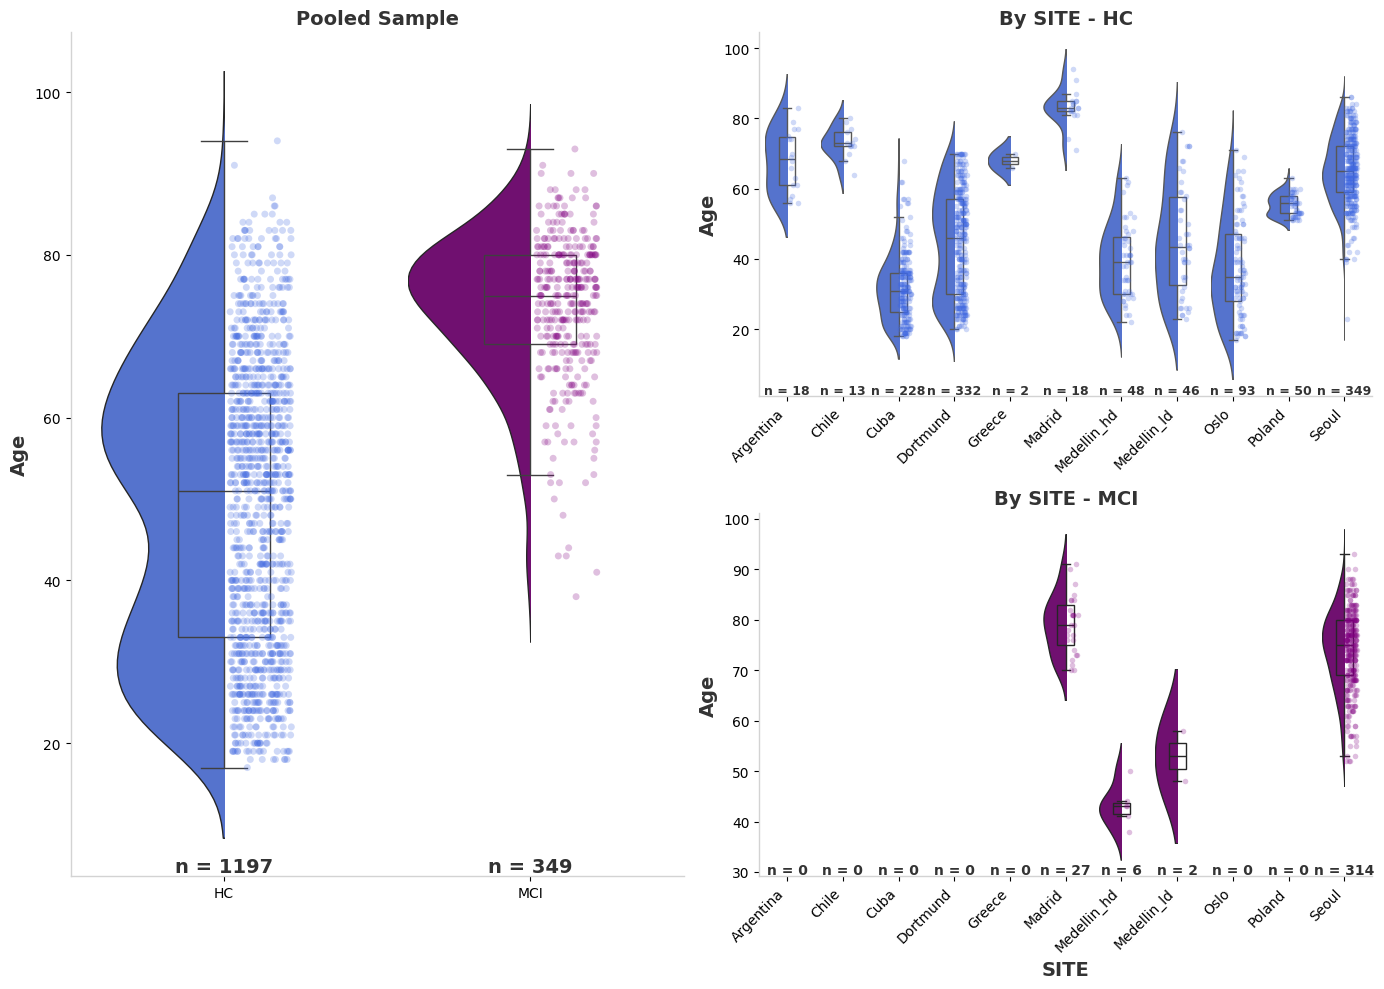

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Unificar datos en un solo DataFrame (asumiendo que 'IAF_FOOOF_age' ya existe)
IAF_FOOOF_age = IAF_FOOOF_age[IAF_FOOOF_age['group'].isin(['HC', 'MCI'])].copy()

# CREAR un nuevo identificador compuesto
IAF_FOOOF_age['subject_site'] = IAF_FOOOF_age['subject'].astype(str) + '_' + IAF_FOOOF_age['SITE'].astype(str)

# El resto sigue igual
group_order = ["HC", "MCI"]
sorted_sites = sorted(IAF_FOOOF_age['SITE'].unique(), key=lambda x: str(x))

palette = {'HC': 'royalblue', 'MCI': 'purple'}

# Crear la figura y la cuadrícula: 
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1])

ax_pool = fig.add_subplot(gs[:, 0])   # Ocupa la columna 0, ambas filas
ax_hc   = fig.add_subplot(gs[0, 1])   # Columna 1, fila superior
ax_mci  = fig.add_subplot(gs[1, 1])   # Columna 1, fila inferior

# ----- POOLED SAMPLE (ax_pool) -----
sns.violinplot(
    x="group", y="age", data=IAF_FOOOF_age,
    hue="group", dodge=False,
    palette=palette, scale="width", inner=None,
    ax=ax_pool, linewidth=1, order=group_order
)
for violin in ax_pool.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_pool.transData)
    )

sns.boxplot(
    x="group", y="age", data=IAF_FOOOF_age,
    width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_pool, order=group_order
)
old_len = len(ax_pool.collections)
sns.stripplot(
    x="group", y="age", data=IAF_FOOOF_age,
    hue="group", dodge=False,
    palette=palette, ax=ax_pool, alpha=0.25, size=5,
    order=group_order
)
for dots in ax_pool.collections[old_len:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada grupo
group_counts = IAF_FOOOF_age.groupby("group")["subject_site"].nunique().to_dict()
print(group_counts)
for i, group in enumerate(group_order):
    count = group_counts.get(group, 0)
    ax_pool.text(i, ax_pool.get_ylim()[0] + 0.5, f"n = {count}",
                 ha='center', fontsize=14, fontweight='bold', color='#333')

ax_pool.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_pool.set_xlabel("")
ax_pool.set_title("Pooled Sample", fontsize=14, fontweight='bold', color='#333')
ax_pool.grid(False)
ax_pool.set_facecolor('none')
ax_pool.spines['top'].set_visible(False)
ax_pool.spines['right'].set_visible(False)
for spine in ax_pool.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)

# ----- BY SITE - HC (ax_hc) -----
IAF_FOOOF_age_hc = IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'HC']

sns.violinplot(
    x="SITE", y="age", data=IAF_FOOOF_age_hc,
    dodge=False, color=palette['HC'], scale="width", inner=None,
    ax=ax_hc, linewidth=1, order=sorted_sites
)
for violin in ax_hc.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_hc.transData)
    )

sns.boxplot(
    x="SITE", y="age", data=IAF_FOOOF_age_hc,
    dodge=False, width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_hc, order=sorted_sites, color=palette['HC']
)
old_len_hc = len(ax_hc.collections)
sns.stripplot(
    x="SITE", y="age", data=IAF_FOOOF_age_hc,
    dodge=False, color=palette['HC'], ax=ax_hc, alpha=0.25, size=4,
    order=sorted_sites
)
for dots in ax_hc.collections[old_len_hc:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada sitio en HC (CORREGIDO)
for i, site in enumerate(sorted_sites):
    count = IAF_FOOOF_age_hc[IAF_FOOOF_age_hc['SITE'] == site]['subject_site'].nunique()
    ax_hc.text(i, ax_hc.get_ylim()[0] + 0.5, f"n = {count}", ha='center',
               fontsize=9, fontweight='bold', color='#333')

ax_hc.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_hc.set_xlabel("")
ax_hc.set_title("By SITE - HC", fontsize=14, fontweight='bold', color='#333')
ax_hc.grid(False)
ax_hc.set_facecolor('none')
ax_hc.spines['top'].set_visible(False)
ax_hc.spines['right'].set_visible(False)
for spine in ax_hc.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)
ax_hc.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)

# ----- BY SITE - MCI (ax_mci) -----
IAF_FOOOF_age_mci = IAF_FOOOF_age[IAF_FOOOF_age['group'] == 'MCI']

sns.violinplot(
    x="SITE", y="age", data=IAF_FOOOF_age_mci,
    dodge=False, color=palette['MCI'], scale="width", inner=None,
    ax=ax_mci, linewidth=1, order=sorted_sites
)
for violin in ax_mci.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        plt.Rectangle((x0, y0), width / 2, height, transform=ax_mci.transData)
    )

sns.boxplot(
    x="SITE", y="age", data=IAF_FOOOF_age_mci,
    dodge=False, width=0.3, saturation=1,
    showfliers=False, boxprops={'facecolor': 'none', 'zorder': 3},
    ax=ax_mci, order=sorted_sites, color=palette['MCI']
)
old_len_mci = len(ax_mci.collections)
sns.stripplot(
    x="SITE", y="age", data=IAF_FOOOF_age_mci,
    dodge=False, color=palette['MCI'], ax=ax_mci, alpha=0.25, size=4,
    order=sorted_sites
)
for dots in ax_mci.collections[old_len_mci:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

# Etiquetas "n = X" para cada sitio en MCI (CORREGIDO)
for i, site in enumerate(sorted_sites):
    count = IAF_FOOOF_age_mci[IAF_FOOOF_age_mci['SITE'] == site]['subject_site'].nunique()
    ax_mci.text(i, ax_mci.get_ylim()[0] + 0.5, f"n = {count}", ha='center',
                fontsize=10, fontweight='bold', color='#333')

ax_mci.set_ylabel("Age", fontsize=14, fontweight='bold', color='#333')
ax_mci.set_xlabel("SITE", fontsize=14, fontweight='bold', color='#333')
ax_mci.set_title("By SITE - MCI", fontsize=14, fontweight='bold', color='#333')
ax_mci.grid(False)
ax_mci.set_facecolor('none')
ax_mci.spines['top'].set_visible(False)
ax_mci.spines['right'].set_visible(False)
for spine in ax_mci.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1)
ax_mci.set_xticklabels(sorted_sites, rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig(r"D:\MulticentersEEG\graphs_thesis_LMZS\post_age_distribution_by_site.pdf", dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.show()


In [57]:
#dfs =[dem_Dortmund, dem_CHBMP, dem_GREECE, dem_AR, dem_CL, dem_PORTABLES_CE, dem_BIOMARCADORES, dem_Poland, dem_SRM, dem_Madrid_c3n]
dfs =[dem_PORTABLES_CE, dem_BIOMARCADORES, dem_Poland, dem_SRM, dem_Madrid_c3n, dem_CAUEEG_CONCAT]
for df in dfs:
    site_name = df["SITE"].unique()[0]
    print(f"{site_name}")

    if 'sex' in df.columns and 'group' in df.columns:
        for group in ['HC', 'MCI']:
            df_group = df[df['group'] == group]
            if not df_group.empty:
                # Calcular media y desviación estándar general del grupo
                mean_age, std_age = df_group['age'].mean(), df_group['age'].std()
                if 'education' in df.columns:
                    mean_education, std_education = df_group['education'].mean(), df_group['education'].std()
                    print(f"Educación: μ={mean_education:.1f}, σ={std_education:.1f}")
                # Contar cantidad de hombres y mujeres
                count_sex = df_group['sex'].value_counts()
                count_m = count_sex.get('M', 0)
                count_f = count_sex.get('F', 0)

                print(f"Grupo {group}: μ={mean_age:.1f}, σ={std_age:.1f} | Hombres: {count_m}, Mujeres: {count_f}")

    elif 'group' in df.columns:
        for group in ['HC', 'MCI']:
            df_group = df[df['group'] == group]
            if not df_group.empty:
                mean_age, std_age = df_group['age'].mean(), df_group['age'].std()
                if 'sex' in df.columns:
                    count_sex = df_group['sex'].value_counts()
                    count_m = count_sex.get('M', 0)
                    count_f = count_sex.get('F', 0)
                    print(f"Grupo {group}: μ={mean_age:.1f}, σ={std_age:.1f} | Hombres: {count_m}, Mujeres: {count_f}")
                else:
                    print(f"Grupo {group}: μ={mean_age:.1f}, σ={std_age:.1f}")
    else:
        mean_age, std_age = df['age'].mean(), df['age'].std()
        print(f"Sin grupo específico: μ={mean_age:.1f}, σ={std_age:.1f}")



Medellin_ld
Educación: μ=13.1, σ=3.6
Grupo HC: μ=46.4, σ=14.7 | Hombres: 17, Mujeres: 47
Educación: μ=9.7, σ=3.8
Grupo MCI: μ=47.2, σ=5.6 | Hombres: 5, Mujeres: 4
Medellin_hd
Educación: μ=10.8, σ=4.4
Grupo HC: μ=40.0, σ=10.8 | Hombres: 29, Mujeres: 43
Educación: μ=6.9, σ=5.4
Grupo MCI: μ=47.1, σ=5.9 | Hombres: 9, Mujeres: 11
Poland
Educación: μ=2.7, σ=0.7
Grupo HC: μ=55.3, σ=3.1 | Hombres: 38, Mujeres: 40
Oslo
Grupo HC: μ=37.6, σ=14.0 | Hombres: 42, Mujeres: 69
Madrid
Educación: μ=14.7, σ=5.7
Grupo HC: μ=83.1, σ=4.7 | Hombres: 10, Mujeres: 13
Educación: μ=14.3, σ=6.3
Grupo MCI: μ=79.6, σ=5.7 | Hombres: 10, Mujeres: 26
Seoul
Grupo HC: μ=65.1, σ=9.5
Grupo MCI: μ=73.8, σ=7.8


#### Plots preprocessing APPLEE

In [31]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [32]:
Wavelet = mne.io.read_raw(r'F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-wavelet_eeg.fif')
Wica = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-wica_eeg.fif")
reject = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-reject_eeg.fif")
muscle  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif")
scorEpochs  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-scorEpoch_24_eeg.fif")

Opening raw data file F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 59999 =      0.000 ...   299.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-wica_eeg.fif...
Isotrak not found
    Range : 0 ... 59999 =      0.000 ...   299.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-reject_eeg.fif...
Isotrak not found
    Range : 0 ... 45999 =      0.000 ...   229.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\APPLEE\sub-CTR001\ses-V0\eeg\sub-CTR001_ses-V0_task-CE_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif...
    Range : 0 ... 45999 =      0.000 ...   229.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_PO

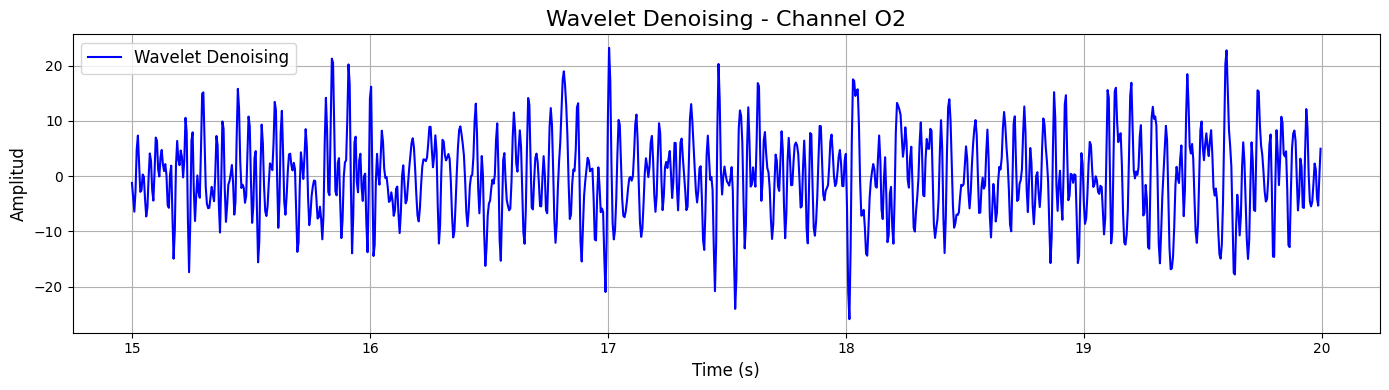

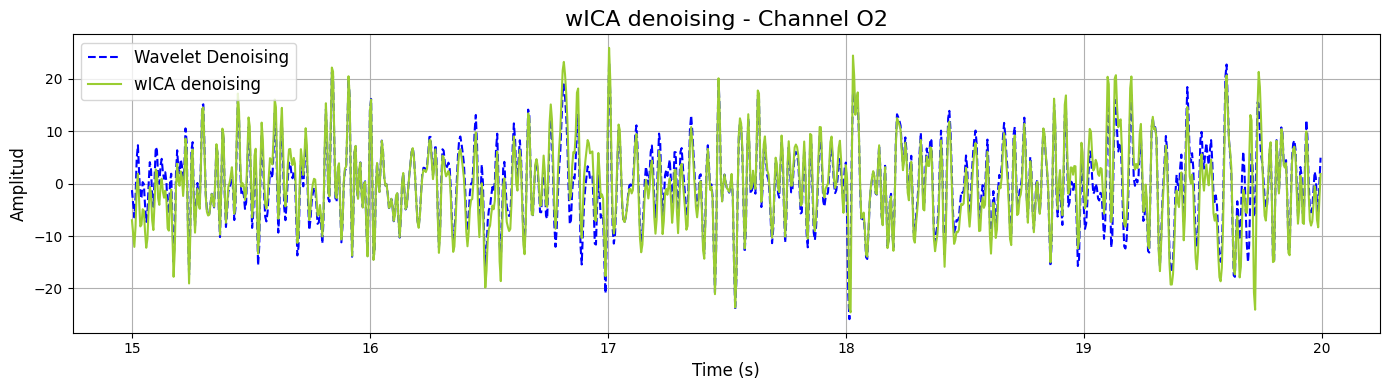

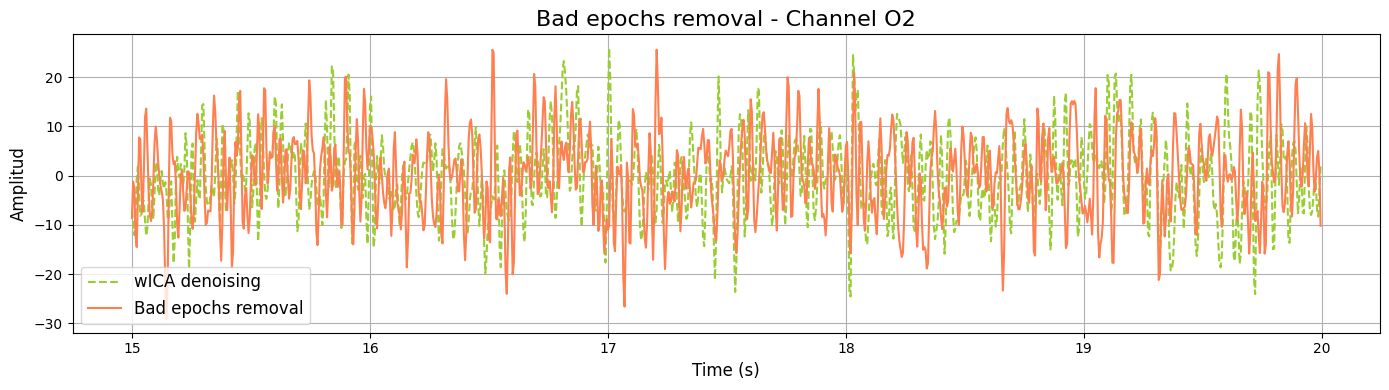

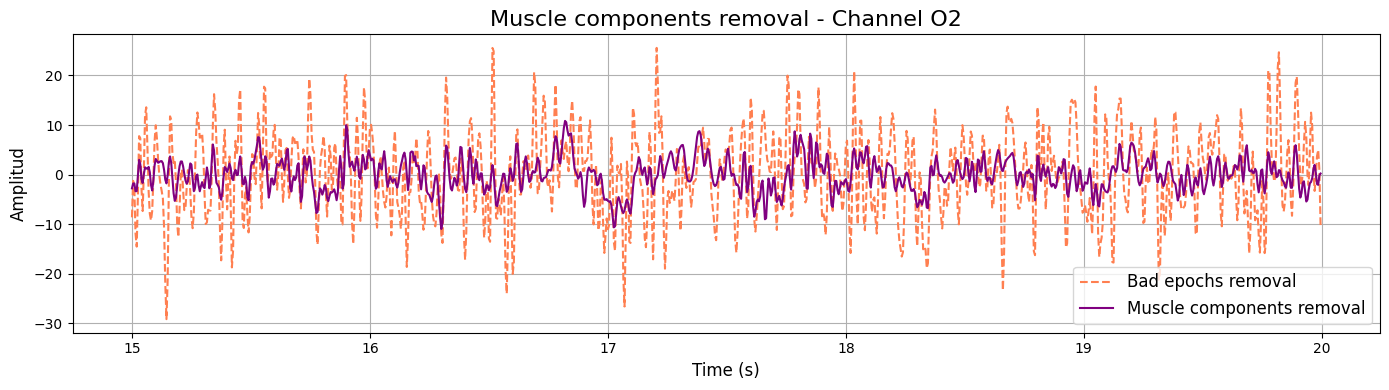

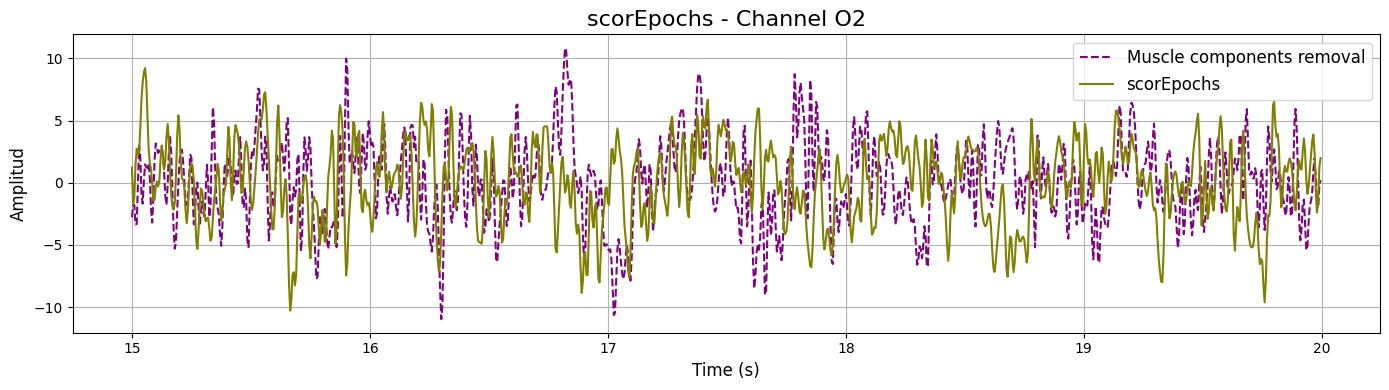

In [33]:
import matplotlib.pyplot as plt

# Lista de objetos Raw y sus etiquetas correspondientes
raws   = [Wavelet, Wica, reject, muscle, scorEpochs]
etapas = ["Wavelet Denoising", "wICA denoising", "Bad epochs removal", "Muscle components removal", "scorEpochs"]
colors = ['blue', 'yellowgreen', 'coral', 'purple', 'olive']

channel   = "O2"
sfreq     = Wavelet.info['sfreq']   # Se asume que la frecuencia es la misma en todos los objetos
n_samples = int(sfreq * 5)         # Número de muestras correspondientes a 10 segundos

# Cambiamos el estilo a 'default' para evitar el fondo gris
plt.style.use('default')

# Iterar sobre cada etapa para generar gráficos independientes
for i in range(len(raws)):
    plt.figure(figsize=(14, 4))
    
    if i == 0:
        # Primer gráfico: solo se grafica la etapa Wavelet Denoising (línea continua)
        try:
            ch_idx = raws[i].ch_names.index(channel)
        except ValueError:
            plt.text(0.5, 0.5, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
            plt.show()
            continue
        
        data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
        data_10s  = data[0, n_samples*3 : n_samples*4]
        times_10s = times[n_samples*3 : n_samples*4]
        
        plt.plot(times_10s, data_10s, color=colors[i],
                 linestyle='-', linewidth=1.5, label=etapas[i])
        plt.title(f"{etapas[i]} - Channel {channel}", fontsize=16)
    
    else:
        # Para las siguientes etapas: se grafican dos curvas:
        #   1. La etapa anterior en línea punteada.
        try:
            ch_idx_prev = raws[i-1].ch_names.index(channel)
            data_prev, times_prev = raws[i-1].get_data(picks=[ch_idx_prev], return_times=True)
            data_prev_10s  = data_prev[0, n_samples*3 : n_samples*4]
            times_prev_10s = times_prev[n_samples*3 : n_samples*4]
            plt.plot(times_prev_10s, data_prev_10s, color=colors[i-1],
                     linestyle='--', linewidth=1.5, label=etapas[i-1])
        except ValueError:
            plt.text(0.5, 0.7, f"Canal '{channel}' no encontrado en {etapas[i-1]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        #   2. La etapa actual en línea continua.
        try:
            ch_idx = raws[i].ch_names.index(channel)
            data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
            data_10s  = data[0, n_samples*3 : n_samples*4]
            times_10s = times[n_samples*3 : n_samples*4]
            plt.plot(times_10s, data_10s, color=colors[i],
                     linestyle='-', linewidth=1.5, label=etapas[i])
        except ValueError:
            plt.text(0.5, 0.3, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        plt.title(f"{etapas[i]} - Channel O2", fontsize=16)
    
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


In [34]:
from scipy import stats
data = stats.zscore(scorEpochs.get_data(),axis=1)
data.shape

(8, 24000)

In [35]:
data = stats.zscore(scorEpochs.get_data(),axis=1)

In [36]:
scorEpochs.get_data().shape

(8, 24000)

In [37]:
scorEpochs

<Raw | sub-CTR001_ses-V0_task-CE_desc-scorEpoch_24_eeg.fif, 8 x 24000 (120.0 s), ~16 kB, data not loaded>

In [38]:
scorEpochs.get_data().mean(axis=1)

array([ 0.01244968,  0.01624356, -0.00066479, -0.01944953,  0.00624434,
       -0.01841051,  0.05404384,  0.0681841 ])

In [39]:
means = np.mean(scorEpochs.get_data(), axis=1, keepdims=True)
stds  = np.std(scorEpochs.get_data(), axis=1, keepdims=True)

# Aplicar la fórmula del zscore: (x - media) / std
data_z = (scorEpochs.get_data() - means) / stds

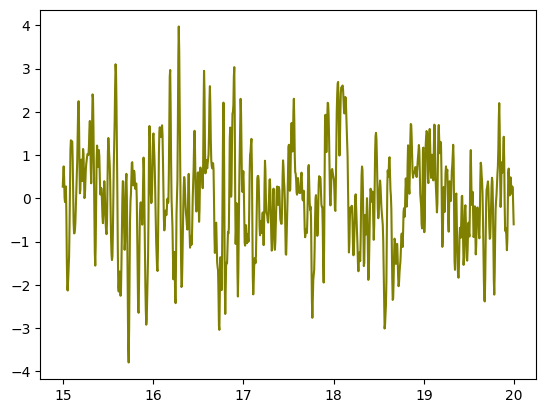

In [40]:
data_10s  = data[0, n_samples*3 : n_samples*4]
times_10s = times[n_samples*3 : n_samples*4]
plt.plot(times_10s, data_10s, color=colors[i],
linestyle='-', linewidth=1.5, label=etapas[i])

In [41]:
Wavelet = mne.io.read_raw(r'F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif')
Wica = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif")
reject = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif")
muscle  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif")
scorEpochs  = mne.io.read_raw(r"F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-scorEpoch_24_eeg.fif")

Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wavelet_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-wica_eeg.fif...
Isotrak not found
    Range : 0 ... 60999 =      0.000 ...   304.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-reject_eeg.fif...
Isotrak not found
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MUSCA_OO\derivatives\APPLEE\sub-DCLSTIM001\ses-eeg\eeg\sub-DCLSTIM001_ses-eeg_task-rest_desc-Muscle_sm0.7_ct0.2_fb0.05_eeg.fif...
    Range : 0 ... 46999 =      0.000 ...   234.995 secs
Ready.
Opening raw data file F:\EEG_MULTICENTER\BIDS_MU

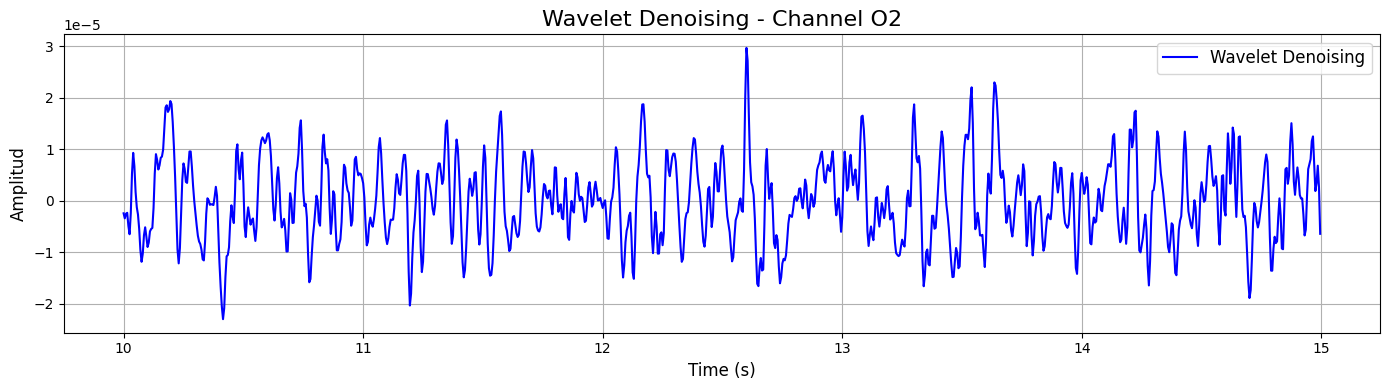

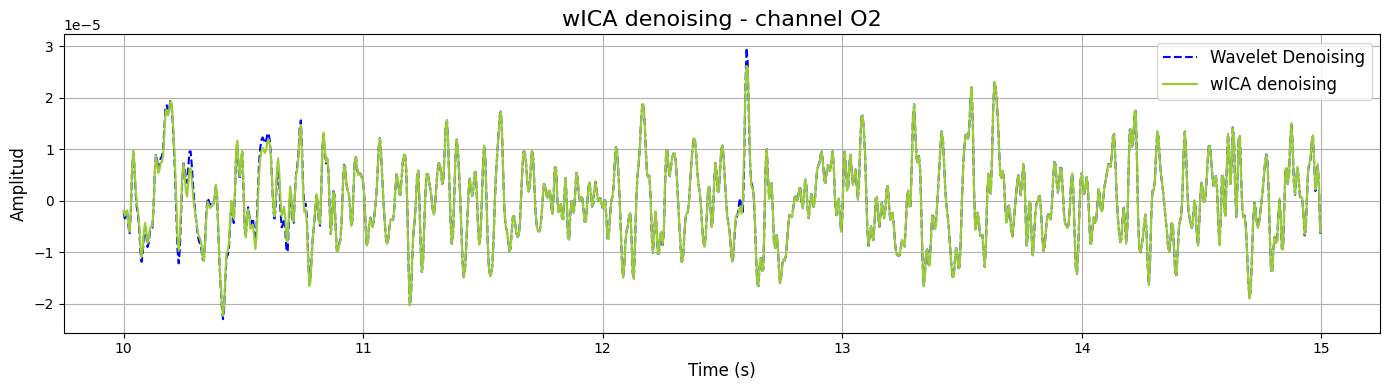

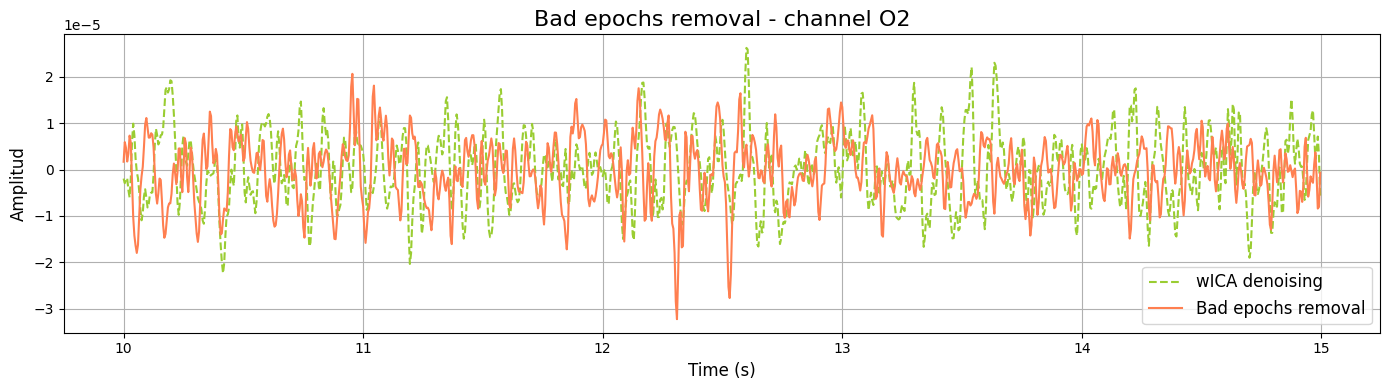

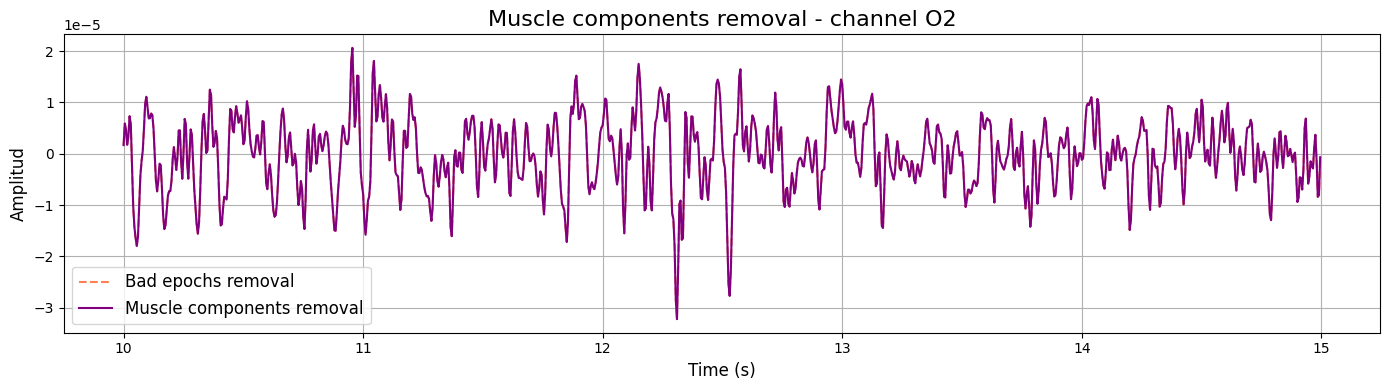

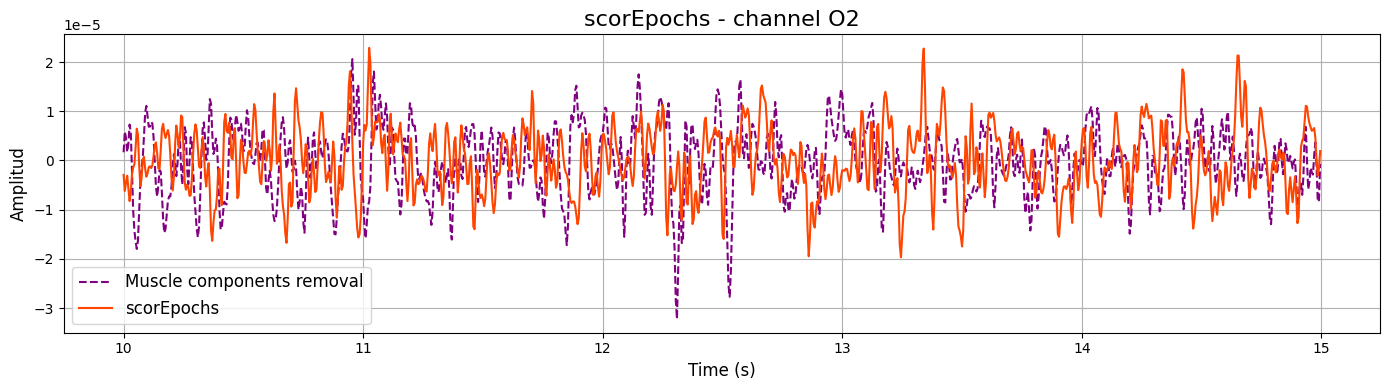

In [42]:
import matplotlib.pyplot as plt

# Lista de objetos Raw y sus etiquetas correspondientes
raws   = [Wavelet, Wica, reject, muscle, scorEpochs]
etapas = ["Wavelet Denoising", "wICA denoising", "Bad epochs removal", "Muscle components removal", "scorEpochs"]
colors = ['blue', 'yellowgreen', 'coral', 'purple', 'orangered']

channel   = "O2"
sfreq     = Wavelet.info['sfreq']   # Se asume que la frecuencia es la misma en todos los objetos
n_samples = int(sfreq * 5)         # Número de muestras correspondientes a 10 segundos

# Cambiamos el estilo a 'default' para evitar el fondo gris
plt.style.use('default')

# Iterar sobre cada etapa para generar gráficos independientes
for i in range(len(raws)):
    plt.figure(figsize=(14, 4))
    
    if i == 0:
        # Primer gráfico: solo se grafica la etapa Wavelet Denoising (línea continua)
        try:
            ch_idx = raws[i].ch_names.index(channel)
        except ValueError:
            plt.text(0.5, 0.5, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
            plt.show()
            continue
        
        data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
        data_10s  = data[0, n_samples*2 : n_samples*3]
        times_10s = times[n_samples*2 : n_samples*3]
        
        plt.plot(times_10s, data_10s, color=colors[i],
                 linestyle='-', linewidth=1.5, label=etapas[i])
        plt.title(f"{etapas[i]} - Channel {channel}", fontsize=16)
    
    else:
        # Para las siguientes etapas: se grafican dos curvas:
        #   1. La etapa anterior en línea punteada.
        try:
            ch_idx_prev = raws[i-1].ch_names.index(channel)
            data_prev, times_prev = raws[i-1].get_data(picks=[ch_idx_prev], return_times=True)
            data_prev_10s  = data_prev[0, n_samples*2 : n_samples*3]
            times_prev_10s = times_prev[n_samples*2 : n_samples*3]
            plt.plot(times_prev_10s, data_prev_10s, color=colors[i-1],
                     linestyle='--', linewidth=1.5, label=etapas[i-1])
        except ValueError:
            plt.text(0.5, 0.7, f"Canal '{channel}' no encontrado en {etapas[i-1]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        #   2. La etapa actual en línea continua.
        try:
            ch_idx = raws[i].ch_names.index(channel)
            data, times = raws[i].get_data(picks=[ch_idx], return_times=True)
            data_10s  = data[0, n_samples*2 : n_samples*3]
            times_10s = times[n_samples*2 : n_samples*3]
            plt.plot(times_10s, data_10s, color=colors[i],
                     linestyle='-', linewidth=1.5, label=etapas[i])
        except ValueError:
            plt.text(0.5, 0.3, f"Canal '{channel}' no encontrado en {etapas[i]}",
                     transform=plt.gca().transAxes, ha='center', fontsize=12)
        
        plt.title(f"{etapas[i]} - channel O2", fontsize=16)
    
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
